# Part 1: Linear Regression & Optimization 📉

Welcome to the foundation of Deep Learning!

Before we build complex Neural Networks, we must understand the simplest building block: **The Linear Unit**.

**Goals of this notebook:**
1.  **Theory:** Why "Deep" Linear Networks are useless (The Linear Collapse).
2.  **The Math:** Implement the **Closed Form Solution** (Normal Equation) manually using Matrix operations.
3.  **The Loss:** Understand **MSE** (Mean Squared Error).
4.  **Optimization:** Implement **Gradient Descent (SGD)** from scratch.

---

In [134]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Setup Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✅ Using device: {device}")

✅ Using device: cpu


## 1. Theory: What is a Linear Model?

The Linear Regression model predicts a target $y$ based on input features $X$ using a weighted sum:

$$ \hat{y} = w_1 x_1 + w_2 x_2 + ... + w_d x_d + b $$

In matrix notation (vectorized):
$$ \hat{y} = Xw + b $$

### ❓ Why don't we make it "Deep"?
You might ask: *"If deep learning is so good, why don't we stack 10 Linear Regressions on top of each other?"*

Imagine we have 2 layers. 
* Layer 1: $h = X W_1$
* Layer 2: $y = h W_2$

Substitute $h$ into the second equation:
$$ y = (X W_1) W_2 = X (W_1 W_2) $$

Since matrix multiplication is associative, we can just multiply $W_1$ and $W_2$ to get a new matrix $W_{new}$.
$$ y = X W_{new} $$

**Conclusion:** Stacking linear layers without non-linearities (like ReLU or Sigmoid) is mathematically equivalent to just **one single linear layer**. 
* **Width:** Increasing width (more features) helps if the features are relevant.
* **Depth:** Increasing depth (more layers) is **useless** for purely linear models.

This is why we need **Activation Functions** in Deep Learning!

## 2. Data Preparation
We use the **California Housing** dataset. 
* **X (Features):** House Age, Rooms, Population, etc.
* **y (Target):** House Price.

In [135]:
# 1. Load Data
try:
    df = pd.read_csv('Datasets/Housing/california_housing.csv')
except FileNotFoundError:
    # Fallback if downloaded manually
    from sklearn.datasets import fetch_california_housing
    housing = fetch_california_housing(as_frame=True)
    df = housing.frame

# 2. Preprocessing
X = df.drop('MedHouseVal', axis=1).values
y = df['MedHouseVal'].values

# Standardization (Crucial for Linear Regression!)
# We force the data to have Mean=0 and Std=1.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Split Train/Test
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# 4. To PyTorch Tensors
X_train_t = torch.tensor(X_train, dtype=torch.float32).to(device)
y_train_t = torch.tensor(y_train, dtype=torch.float32).view(-1, 1).to(device)
X_test_t = torch.tensor(X_test, dtype=torch.float32).to(device)
y_test_t = torch.tensor(y_test, dtype=torch.float32).view(-1, 1).to(device)

print(f"Feature Shape (N, D): {X_train_t.shape}")

Feature Shape (N, D): torch.Size([16512, 8])


In [ ]:
df

## 3. The Objective: Mean Squared Error (MSE)

How do we know if our weights $w$ are good?
We measure the "distance" between prediction $\hat{y}$ and truth $y$.

$$ MSE = \frac{1}{N} \sum_{i=1}^{N} (y_i - \hat{y}_i)^2 $$

**Why Squared?**
1.  **Positivity:** $(y-\hat{y})^2$ is always positive. Errors don't cancel each other out.
2.  **Penalize Outliers:** If the error is 2, squared error is 4. If error is 10, squared error is 100! The model hates being "very wrong".
3.  **Convexity:** The graph of $x^2$ is a bowl (parabola). It has one clear bottom (Global Minimum). This makes it easy to optimize.

## 4. The Closed Form Solution (Normal Equation) 📐

For Linear Regression (and only for it), we can find the perfect $w$ instantly using algebra, without any training loops.

The formula is derived by setting the derivative of the Loss to 0:
$$ w^* = (X^T X)^{-1} X^T y $$

Let's implement this step-by-step and track the **Tensor Shapes**.

In [136]:
# 0. Prepare Bias Term
# Linear regression needs y = wX + b.
# Math trick: We add a column of 1s to X, so the bias 'b' becomes just another weight w_0.

N, D = X_train_t.shape  # N = Samples (approx 16k), D = Features (8)

# Create column of ones [N, 1]
ones = torch.ones(N, 1).to(device) 

# Concatenate: New shape is [N, D+1]
X_b = torch.cat([ones, X_train_t], dim=1) 

print(f"Original X: {X_train_t.shape}")
print(f"X with Bias: {X_b.shape}  <-- Added column of 1s")

# --- THE FORMULA: w = (X^T * X)^-1 * X^T * y ---

# 1. X Transpose * X (The Gram Matrix)
# Shape: [D+1, N] @ [N, D+1] -> [D+1, D+1]
# This creates a small square matrix (correlation of features)
XT_X = X_b.t().mm(X_b)

# 2. Inverse
# Shape: [D+1, D+1] -> [D+1, D+1]
# This step is slow if D is huge (millions), but fast for D=8.
XT_X_inv = torch.inverse(XT_X)

# 3. X Transpose * y
# Shape: [D+1, N] @ [N, 1] -> [D+1, 1]
# This projects the target y onto the feature space.
XT_y = X_b.t().mm(y_train_t)

# 4. Final Multiplication
# Shape: [D+1, D+1] @ [D+1, 1] -> [D+1, 1]
# Result is our vector of optimal weights!
w_optimal = XT_X_inv.mm(XT_y)

print("\n✅ Calculated Optimal Weights:")
print(w_optimal.flatten()) # Flatten just for cleaner printing

Original X: torch.Size([16512, 8])
X with Bias: torch.Size([16512, 9])  <-- Added column of 1s

✅ Calculated Optimal Weights:
tensor([ 2.0679,  0.8524,  0.1224, -0.3051,  0.3711, -0.0023, -0.0366, -0.8966,
        -0.8689])


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

my_model = LinearRegression(fit_intercept=True).fit(X_train, y_train)

In [ ]:
my_model.coef_

In [ ]:
my_model.intercept_

In [ ]:
aaa = np.asarray(w_optimal[1:]).reshape(-1,1)
bbb = np.asarray(my_model.coef_).reshape(-1,1)

In [ ]:
from sklearn.metrics import r2_score

In [ ]:
print(mean_squared_error(aaa, bbb))
print(r2_score(aaa, bbb))

### Verification
Let's check the MSE of this analytical solution. This is mathematically the **best possible error** for a linear model on this data.

In [137]:
# Prepare Test Data (Add ones)
ones_test = torch.ones(X_test_t.shape[0], 1).to(device)
X_test_b = torch.cat([ones_test, X_test_t], dim=1)

# Predict: y = X * w
# Shape: [N_test, D+1] @ [D+1, 1] -> [N_test, 1]
predictions = X_test_b.mm(w_optimal)

# Calculate MSE
mse_loss = torch.mean((predictions - y_test_t)**2)

print(f"📉 Closed Form Test MSE: {mse_loss.item():.4f}")

📉 Closed Form Test MSE: 0.5559


## 5. Gradient Descent (The Deep Learning Way) ⛷️

Why don't we always use the Closed Form?
1.  **Inversion is expensive:** Inverting a matrix is $O(D^3)$. If you have 100,000 features (e.g., pixels in an image), inverting the matrix is impossible.
2.  **Memory:** Storing $X^T X$ takes too much RAM for big data.

Instead, we use **Gradient Descent**.

$$ w \leftarrow w - \eta \cdot \nabla L $$

We calculate the slope (gradient) and take a small step ($\eta$) downhill.

In [138]:
# 1. Initialize random weights
# We use PyTorch's nn.Linear which handles the bias automatically
model = torch.nn.Linear(X_train.shape[1], 1).to(device)

# 2. Define Optimizer
# SGD = Stochastic Gradient Descent
# lr = Learning Rate (Step size)
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)

# 3. Define Loss Function
criterion = torch.nn.MSELoss()

loss_history = []

print("🚀 Starting Gradient Descent...")

for epoch in range(500):
    # Forward Pass: Predict y
    predictions = model(X_train_t)
    
    # Calculate Loss
    loss = criterion(predictions, y_train_t)
    
    # Backward Pass: Calculate Gradients
    optimizer.zero_grad() # Clear previous gradients
    loss.backward()       # Compute dLoss/dw
    optimizer.step()      # Update weights
    
    loss_history.append(loss.item())
    
    if epoch % 50 == 0:
        print(f"Epoch {epoch}: MSE = {loss.item():.4f}")

print(f"\n🏁 Final SGD Loss: {loss_history[-1]:.4f}")
print(f"(Compare with Closed Form: {mse_loss.item():.4f}) -> They should be close!")

🚀 Starting Gradient Descent...
Epoch 0: MSE = 6.5322
Epoch 50: MSE = 1.3773
Epoch 100: MSE = 0.7027
Epoch 150: MSE = 0.6036
Epoch 200: MSE = 0.5817
Epoch 250: MSE = 0.5713
Epoch 300: MSE = 0.5635
Epoch 350: MSE = 0.5570
Epoch 400: MSE = 0.5514
Epoch 450: MSE = 0.5467

🏁 Final SGD Loss: 0.5427
(Compare with Closed Form: 0.5559) -> They should be close!


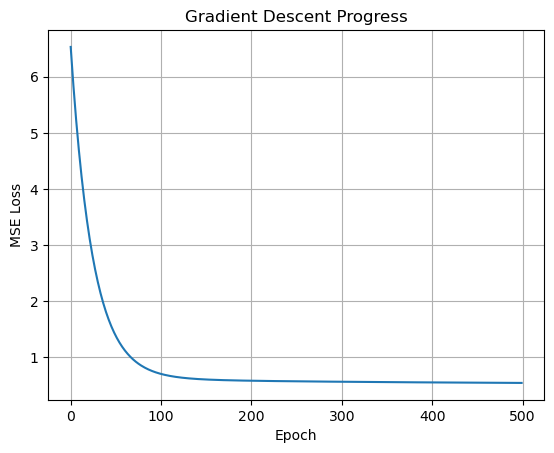

In [140]:
plt.plot(loss_history)
plt.title("Gradient Descent Progress")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.grid()
plt.show()

## 6. Final Comparison on Test Data 💰

The plot above shows the **MSE (Squared Error)** during training. This is an abstract mathematical value.

To understand how good the model is in the real world, let's calculate the **MAE (Mean Absolute Error)** on the **Test Set**.

**Important:** In this dataset, the target variable (price) is in units of **$100,000**. Therefore, if the model error is `1.0`, it means an actual error of `$100,000`.

In [146]:
# 1. Switch model to evaluation mode (no gradient tracking)
model.eval()

with torch.no_grad():
    # --- A. Gradient Descent (SGD) Predictions ---
    pred_sgd = model(X_test_t)

    # --- B. Closed Form (Math) Predictions ---
    # We need to add the bias column (ones) manually again for the math solution
    ones_test = torch.ones(X_test_t.shape[0], 1).to(device)
    X_test_b = torch.cat([ones_test, X_test_t], dim=1)
    pred_closed = X_test_b.mm(w_optimal)

# 2. Function to convert error to Dollars
def calculate_dollar_error(predictions, targets):
    # Calculate absolute difference |y_pred - y_true|
    absolute_error = torch.abs(predictions - targets)
    
    # Mean Absolute Error (MAE)
    mae = torch.mean(absolute_error).item()
    
    # Total Sum of Errors (across all test houses)
    total_error = torch.sum(absolute_error).item()
    
    # Multiply by 100,000 because dataset units are in hundreds of thousands
    return mae * 100000, total_error * 100000

mae_sgd, sum_sgd = calculate_dollar_error(pred_sgd, y_test_t)
mae_closed, sum_closed = calculate_dollar_error(pred_closed, y_test_t)

print(f"📊 Results on TEST Set ({len(y_test_t)} houses):\n")

print(f"1. Perfect Math Solution (Closed Form):")
print(f"   - Average Error per House: ${mae_closed:,.2f}")
print(f"   - Total Error Sum:         ${sum_closed:,.0f}")

print(f"\n2. Our Neural Network (SGD):")
print(f"   - Average Error per House: ${mae_sgd:,.2f}")
print(f"   - Total Error Sum:         ${sum_sgd:,.0f}")

print("-"*40)
diff = abs(mae_sgd - mae_closed)
print(f"Difference between Math and SGD: only ${diff:.2f} per house.")

📊 Results on TEST Set (4128 houses):

1. Perfect Math Solution (Closed Form):
   - Average Error per House: $53,320.01
   - Total Error Sum:         $220,105,005

2. Our Neural Network (SGD):
   - Average Error per House: $54,528.06
   - Total Error Sum:         $225,091,821
----------------------------------------
Difference between Math and SGD: only $1208.05 per house.
